In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("../data/cleaned_sales_data.csv")
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
customer_data = df.groupby('Customer_ID').agg({
    'Order_ID': 'nunique',
    'Sales': 'sum',
    'Order_Date': 'max'
}).reset_index()

customer_data.columns = ['Customer_ID', 'Total_Orders', 'Total_Sales', 'Last_Order_Date']

customer_data.head()

,Customer_ID,Total_Orders,Total_Sales,Last_Order_Date
0,AA-10315,5,5563.560,2018-06-29
1,AA-10375,9,1056.390,2018-12-11
2,AA-10480,4,1790.512,2018-04-15
3,AA-10645,6,5086.935,2018-11-05
4,AB-10015,3,886.156,2017-11-10


In [4]:
latest_date = df['Order_Date'].max()

customer_data['Recency'] = (latest_date - customer_data['Last_Order_Date']).dt.days

customer_data.head()

,Customer_ID,Total_Orders,Total_Sales,Last_Order_Date,Recency
0,AA-10315,5,5563.560,2018-06-29,184
1,AA-10375,9,1056.390,2018-12-11,19
2,AA-10480,4,1790.512,2018-04-15,259
3,AA-10645,6,5086.935,2018-11-05,55
4,AB-10015,3,886.156,2017-11-10,415


In [5]:
features = customer_data[['Total_Orders', 'Total_Sales', 'Recency']]

In [6]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

customer_data['Cluster'] = kmeans.fit_predict(scaled_features)

customer_data.head()

,Customer_ID,Total_Orders,Total_Sales,Last_Order_Date,Recency,Cluster
0,AA-10315,5,5563.560,2018-06-29,184,0
1,AA-10375,9,1056.390,2018-12-11,19,0
2,AA-10480,4,1790.512,2018-04-15,259,0
3,AA-10645,6,5086.935,2018-11-05,55,2
4,AB-10015,3,886.156,2017-11-10,415,1


In [8]:
cluster_summary = customer_data.groupby('Cluster')[['Total_Orders', 'Total_Sales', 'Recency']].mean()

cluster_summary

,Total_Orders,Total_Sales,Recency
Cluster,,,
0,5.297872,1783.693390,87.560284
1,3.721739,1561.402023,528.156522
2,8.811765,5170.760298,79.333333


In [9]:
cluster_names = {
    0: 'Regular Customers',
    1: 'High Value Customers',
    2: 'Low Engagement Customers'
}

customer_data['Customer_Segment'] = customer_data['Cluster'].map(cluster_names)

customer_data.head()

,Customer_ID,Total_Orders,Total_Sales,Last_Order_Date,Recency,Cluster,Customer_Segment
0,AA-10315,5,5563.560,2018-06-29,184,0,Regular Customers
1,AA-10375,9,1056.390,2018-12-11,19,0,Regular Customers
2,AA-10480,4,1790.512,2018-04-15,259,0,Regular Customers
3,AA-10645,6,5086.935,2018-11-05,55,2,Low Engagement Customers
4,AB-10015,3,886.156,2017-11-10,415,1,High Value Customers


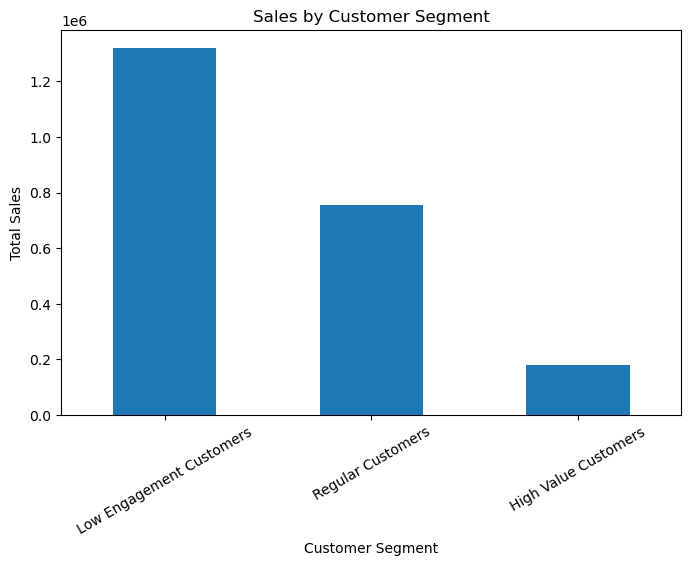

In [10]:
segment_sales = customer_data.groupby('Customer_Segment')['Total_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
segment_sales.plot(kind='bar')
plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=30)
plt.show()

In [11]:
customer_data.to_csv("../data/customer_segments.csv", index=False)

print("Customer segmentation data saved successfully!")

Customer segmentation data saved successfully!
